# Debug Benchmarking - Single Dataset

This notebook helps debug annotation generation for a single dataset.
Use this to manually check shapes, factors, and K-means clustering.

In [8]:
import torch
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
from torch import nn
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF, PCA
import matplotlib.pyplot as plt
import scipy.sparse as sp

# Import GPzoo modules
from gpzoo.kernels import batched_MGGP_RBF, batched_RBF
from gpzoo.gp import MGGP_VNNGP, VNNGP
from gpzoo.likelihoods import NSF2
from gpzoo.utilities import scanpy_sizefactors, dims_autocorr, init_softplus, rescale_spatial_coords

from gpzoo.datasets.tenxvisium.config import REGION_COLUMN, SPATIAL_SCALE

## Configuration

In [9]:
# Choose dataset to debug
dataset_name = '151507'  # Change this to test different datasets

# Paths
data_dir = Path('/gladstone/engelhardt/home/lchumpitaz/gitclones/SDMBench/Data')
models_dir = Path('/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/models/tenxvisium')
output_dir = Path('/gladstone/engelhardt/home/lchumpitaz/gitclones/SDMBench/Benchmarks')

# Model parameters
L = 12  # Number of factors
K = 50  # Number of nearest neighbors

print(f"Dataset: {dataset_name}")
print(f"Region column: {REGION_COLUMN}")
print(f"Spatial scale: {SPATIAL_SCALE}")
print(f"Factors (L): {L}")
print(f"Nearest neighbors (K): {K}")

Dataset: 151507
Region column: Region
Spatial scale: 50.0
Factors (L): 12
Nearest neighbors (K): 50


## Load Data

In [10]:
h5ad_path = data_dir / f"{dataset_name}.h5ad"
print(f"Loading: {h5ad_path}")

adata = ad.read_h5ad(h5ad_path)
print(f"\nOriginal shape: {adata.shape}")
print(f"Obs columns: {list(adata.obs.columns)}")

# Ensure spatial coordinates
if 'X_spatial' in adata.obsm:
    adata.obsm['spatial'] = adata.obsm['X_spatial']

# Remove NaN labels
if REGION_COLUMN in adata.obs.columns:
    adata = adata[np.logical_not(adata.obs[REGION_COLUMN].isna())]
    print(f"After removing NaNs: {adata.shape}")
    
    # Get number of regions
    n_clusters = len(adata.obs[REGION_COLUMN].astype('category').cat.categories)
    print(f"\nNumber of regions (K for K-means): {n_clusters}")
    print(f"Region labels: {list(adata.obs[REGION_COLUMN].astype('category').cat.categories)}")
else:
    n_clusters = 7
    print(f"\nNo {REGION_COLUMN} column found, using default n_clusters={n_clusters}")

Loading: /gladstone/engelhardt/home/lchumpitaz/gitclones/SDMBench/Data/151507.h5ad

Original shape: (4226, 33538)
Obs columns: ['in_tissue', 'array_row', 'array_col', 'Region', 'ground_truth']
After removing NaNs: (4221, 33538)

Number of regions (K for K-means): 7
Region labels: ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'Layer6', 'WM']


## Check Data Sparsity

In [11]:
print("Data format:")
if adata.raw:
    print(f"  raw.X type: {type(adata.raw.X)}")
    print(f"  raw.X shape: {adata.raw.X.shape}")
    if sp.issparse(adata.raw.X):
        print(f"  raw.X is SPARSE")
    else:
        print(f"  raw.X is DENSE")
else:
    print(f"  X type: {type(adata.X)}")
    print(f"  X shape: {adata.X.shape}")
    if sp.issparse(adata.X):
        print(f"  X is SPARSE")
    else:
        print(f"  X is DENSE")

Data format:
  X type: <class 'anndata._core.views.SparseCSRMatrixView'>
  X shape: (4221, 33538)
  X is SPARSE


## 1. PCA Baseline

In [12]:
print("=" * 80)
print("PCA BASELINE")
print("=" * 80)

# Get expression matrix
Y = adata.raw.X if adata.raw else adata.X

# Convert to dense if sparse
if sp.issparse(Y):
    print("Converting sparse to dense...")
    Y = Y.toarray()

print(f"Expression matrix shape: {Y.shape} (cells x genes)")

# PCA
pca_model = PCA(n_components=L, random_state=0)
pca_factors = pca_model.fit_transform(Y)

print(f"PCA factors shape: {pca_factors.shape} (should be N x L = {adata.shape[0]} x {L})")
print(f"PCA factors stats: min={pca_factors.min():.3f}, max={pca_factors.max():.3f}, mean={pca_factors.mean():.3f}")

# K-means
print(f"\nRunning K-means with n_clusters={n_clusters}...")
pca_labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(pca_factors)

print(f"Unique cluster labels: {np.unique(pca_labels)}")
print(f"Label counts: {np.bincount(pca_labels)}")

PCA BASELINE
Converting sparse to dense...
Expression matrix shape: (4221, 33538) (cells x genes)
PCA factors shape: (4221, 12) (should be N x L = 4221 x 12)
PCA factors stats: min=-155.900, max=287.608, mean=0.000

Running K-means with n_clusters=7...
Unique cluster labels: [0 1 2 3 4 5 6]
Label counts: [908 414 480 686 103 894 736]


## 2. NMF Baseline

In [13]:
print("=" * 80)
print("NMF BASELINE")
print("=" * 80)

# Get expression matrix (cells x genes)
Y_cells_genes = adata.raw.X if adata.raw else adata.X

# Convert to dense if sparse
if sp.issparse(Y_cells_genes):
    print("Converting sparse to dense...")
    Y_cells_genes = Y_cells_genes.toarray()

print(f"Expression matrix shape: {Y_cells_genes.shape} (cells x genes)")

# Compute size factors
V = scanpy_sizefactors(Y_cells_genes)
print(f"Size factors shape: {V.shape}")

# NMF
nmf_model = NMF(n_components=L, max_iter=300, init='random', random_state=0, alpha_H=0.0, alpha_W=1e-2)
nmf_model.fit((Y_cells_genes / V))

exp_factors = nmf_model.transform(Y_cells_genes / V) / 5
print(f"NMF exp_factors shape: {exp_factors.shape} (should be N x L = {adata.shape[0]} x {L})")

# Order by Moran's I (just for visualization, not for K-means)
moran_idx, moranI = dims_autocorr(exp_factors, adata.obsm['spatial'])
nmf_factors = exp_factors[:, moran_idx]

print(f"NMF factors shape: {nmf_factors.shape} (should be N x L = {adata.shape[0]} x {L})")
print(f"NMF factors stats: min={nmf_factors.min():.3f}, max={nmf_factors.max():.3f}, mean={nmf_factors.mean():.3f}")

# K-means
print(f"\nRunning K-means with n_clusters={n_clusters}...")
nmf_labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(nmf_factors)

print(f"Unique cluster labels: {np.unique(nmf_labels)}")
print(f"Label counts: {np.bincount(nmf_labels)}")

NMF BASELINE
Converting sparse to dense...
Expression matrix shape: (4221, 33538) (cells x genes)
Size factors shape: (4221, 1)


/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


NMF exp_factors shape: (4221, 12) (should be N x L = 4221 x 12)
here_andata
NMF factors shape: (4221, 12) (should be N x L = 4221 x 12)
NMF factors stats: min=0.000, max=0.119, mean=0.009

Running K-means with n_clusters=7...
Unique cluster labels: [0 1 2 3 4 5 6]
Label counts: [ 184  379  925  253 1301  327  852]


## 3. VNNGP Model

In [14]:
print("=" * 80)
print("VNNGP MODEL")
print("=" * 80)

vnngp_model_path = models_dir / f"{dataset_name}_vnngp_k={K}.pth"
print(f"Model path: {vnngp_model_path}")
print(f"Model exists: {vnngp_model_path.exists()}")

if vnngp_model_path.exists():
    # Prepare data - RESCALE SPATIAL COORDINATES PROPERLY!
    X_np = np.asarray(adata.obsm['spatial'], dtype=np.float32)
    X_np = rescale_spatial_coords(X_np) * SPATIAL_SCALE
    X = torch.tensor(X_np).type(torch.float)
    print(f"IMPORTANT: Applied rescale_spatial_coords() then multiplied by SPATIAL_SCALE={SPATIAL_SCALE}")
    
    # Get expression matrix and convert sparse to dense
    Y_matrix = adata.raw.X.T if adata.raw else adata.X.T
    if sp.issparse(Y_matrix):
        Y_matrix = Y_matrix.toarray()
    Y = torch.tensor(Y_matrix).type(torch.float)
    
    print(f"X shape (spatial, rescaled): {X.shape}")
    print(f"Y shape (genes x cells): {Y.shape}")
    
    D, N = Y.shape
    M = N
    V = scanpy_sizefactors(Y.T.numpy())
    
    # Create model
    Z = nn.Parameter(X.clone(), requires_grad=False)
    kernel = batched_RBF(sigma=1.0, lengthscale=100.0)
    gp = VNNGP(kernel, M=M, jitter=1e-5, K=K)
    
    mu = torch.randn(L, M)
    gp.mu = nn.Parameter(mu)
    Lu = 1e-2 * torch.randn(L, M, K)
    gp.Lu = nn.Parameter(Lu.clone().detach())
    gp.Z = Z
    
    model = NSF2(gp, Y, L=L)
    W = torch.randn(D, L)
    model.W = nn.Parameter(W)
    model.V = nn.Parameter(torch.squeeze(torch.tensor(init_softplus(V)).type(torch.float)))
    
    # Load weights
    print("Loading model weights...")
    model.load_state_dict(torch.load(vnngp_model_path))
    
    # Extract factors
    model.cpu()
    model.eval()
    model.prior.K = K
    
    knn_idx = model.prior.calculate_knn(X)[:, :-1]
    model.prior.knn_idx = knn_idx
    knn_idz = model.prior.calculate_knn(model.prior.Z)[:, 1:]
    model.prior.knn_idz = knn_idz
    
    with torch.no_grad():
        qF, _, _ = model.prior.forward(X=X, verbose=False)
        mean_log = qF.mean.detach().numpy()  # (L, N)
        mean_exp = torch.exp(qF.mean).detach().numpy()
    
    print(f"\nmean_log shape: {mean_log.shape} (should be L x N = {L} x {N})")
    print(f"mean_log stats: min={mean_log.min():.3f}, max={mean_log.max():.3f}, mean={mean_log.mean():.3f}")
    
    # Transpose for K-means (need N x L)
    factors_for_kmeans = mean_log.T
    print(f"\nFactors for K-means shape: {factors_for_kmeans.shape} (should be N x L = {N} x {L})")
    
    # K-means
    print(f"Running K-means with n_clusters={n_clusters}...")
    vnngp_labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(factors_for_kmeans)
    
    print(f"Unique cluster labels: {np.unique(vnngp_labels)}")
    print(f"Label counts: {np.bincount(vnngp_labels)}")
else:
    print("Model not found!")

VNNGP MODEL
Model path: /gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/models/tenxvisium/151507_vnngp_k=50.pth
Model exists: True
IMPORTANT: Applied rescale_spatial_coords() then multiplied by SPATIAL_SCALE=50.0
X shape (spatial, rescaled): torch.Size([4221, 2])
Y shape (genes x cells): torch.Size([33538, 4221])
Loading model weights...

mean_log shape: (12, 4221) (should be L x N = 12 x 4221)
mean_log stats: min=-19.539, max=2.093, mean=-4.765

Factors for K-means shape: (4221, 12) (should be N x L = 4221 x 12)
Running K-means with n_clusters=7...
Unique cluster labels: [0 1 2 3 4 5 6]
Label counts: [521 739 601 501 882 520 457]


## 4. MGGP_VNNGP Model

In [15]:
print("=" * 80)
print("MGGP_VNNGP MODEL")
print("=" * 80)

mggp_model_path = models_dir / f"{dataset_name}_mggp_vnngp_k={K}.pth"
print(f"Model path: {mggp_model_path}")
print(f"Model exists: {mggp_model_path.exists()}")

if mggp_model_path.exists():
    # Prepare data - RESCALE SPATIAL COORDINATES PROPERLY!
    X_np = np.asarray(adata.obsm['spatial'], dtype=np.float32)
    X_np = rescale_spatial_coords(X_np) * SPATIAL_SCALE
    X = torch.tensor(X_np).type(torch.float)
    print(f"IMPORTANT: Applied rescale_spatial_coords() then multiplied by SPATIAL_SCALE={SPATIAL_SCALE}")
    
    # Get expression matrix and convert sparse to dense
    Y_matrix = adata.raw.X.T if adata.raw else adata.X.T
    if sp.issparse(Y_matrix):
        Y_matrix = Y_matrix.toarray()
    Y = torch.tensor(Y_matrix).type(torch.float)
    
    # Get groups
    if REGION_COLUMN in adata.obs.columns:
        groupsX = torch.tensor(adata.obs[REGION_COLUMN].astype('category').cat.codes.values).type(torch.LongTensor)
        n_groups = len(adata.obs[REGION_COLUMN].astype('category').cat.categories)
    else:
        groupsX = torch.zeros(X.shape[0], dtype=torch.long)
        n_groups = 1
    
    print(f"X shape (spatial, rescaled): {X.shape}")
    print(f"Y shape (genes x cells): {Y.shape}")
    print(f"Number of groups: {n_groups}")
    
    D, N = Y.shape
    M = N
    V = scanpy_sizefactors(Y.T.numpy())
    
    # Create model
    Z = nn.Parameter(X.clone(), requires_grad=False)
    groupsZ = nn.Parameter(groupsX.clone(), requires_grad=False)
    kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=100.0, group_diff_param=10.0, n_groups=n_groups)
    gp = MGGP_VNNGP(kernel, M=M, n_groups=n_groups, jitter=1e-5, K=K)
    
    mu = torch.randn(L, M)
    gp.mu = nn.Parameter(mu)
    Lu = 1e-2 * torch.randn(L, M, K)
    gp.Lu = nn.Parameter(Lu.clone().detach())
    gp.Z = Z
    gp.groupsZ = groupsZ
    
    model = NSF2(gp, Y, L=L)
    W = torch.randn(D, L)
    model.W = nn.Parameter(W)
    model.V = nn.Parameter(torch.squeeze(torch.tensor(init_softplus(V)).type(torch.float)))
    
    # Load weights
    print("Loading model weights...")
    model.load_state_dict(torch.load(mggp_model_path))
    
    # Extract factors
    model.cpu()
    model.eval()
    model.prior.K = K
    
    knn_idx = model.prior.calculate_knn(X)[:, :-1]
    model.prior.knn_idx = knn_idx
    knn_idz = model.prior.calculate_knn(model.prior.Z)[:, 1:]
    model.prior.knn_idz = knn_idz
    
    with torch.no_grad():
        qF, _, _ = model.prior.forward(X=X, groupsX=groupsX, verbose=False)
        mean_log = qF.mean.detach().numpy()  # (L, N)
        mean_exp = torch.exp(qF.mean).detach().numpy()
    
    print(f"\nmean_log shape: {mean_log.shape} (should be L x N = {L} x {N})")
    print(f"mean_log stats: min={mean_log.min():.3f}, max={mean_log.max():.3f}, mean={mean_log.mean():.3f}")
    
    # Transpose for K-means (need N x L)
    factors_for_kmeans = mean_log.T
    print(f"\nFactors for K-means shape: {factors_for_kmeans.shape} (should be N x L = {N} x {L})")
    
    # K-means
    print(f"Running K-means with n_clusters={n_clusters}...")
    mggp_labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(factors_for_kmeans)
    
    print(f"Unique cluster labels: {np.unique(mggp_labels)}")
    print(f"Label counts: {np.bincount(mggp_labels)}")
else:
    print("Model not found!")

MGGP_VNNGP MODEL
Model path: /gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/models/tenxvisium/151507_mggp_vnngp_k=50.pth
Model exists: True
IMPORTANT: Applied rescale_spatial_coords() then multiplied by SPATIAL_SCALE=50.0
X shape (spatial, rescaled): torch.Size([4221, 2])
Y shape (genes x cells): torch.Size([33538, 4221])
Number of groups: 7
Loading model weights...

mean_log shape: (12, 4221) (should be L x N = 12 x 4221)
mean_log stats: min=-9.182, max=2.275, mean=-2.901

Factors for K-means shape: (4221, 12) (should be N x L = 4221 x 12)
Running K-means with n_clusters=7...
Unique cluster labels: [0 1 2 3 4 5 6]
Label counts: [ 370  456  585 1057  594  359  800]


## Visualize Ground Truth vs Predictions

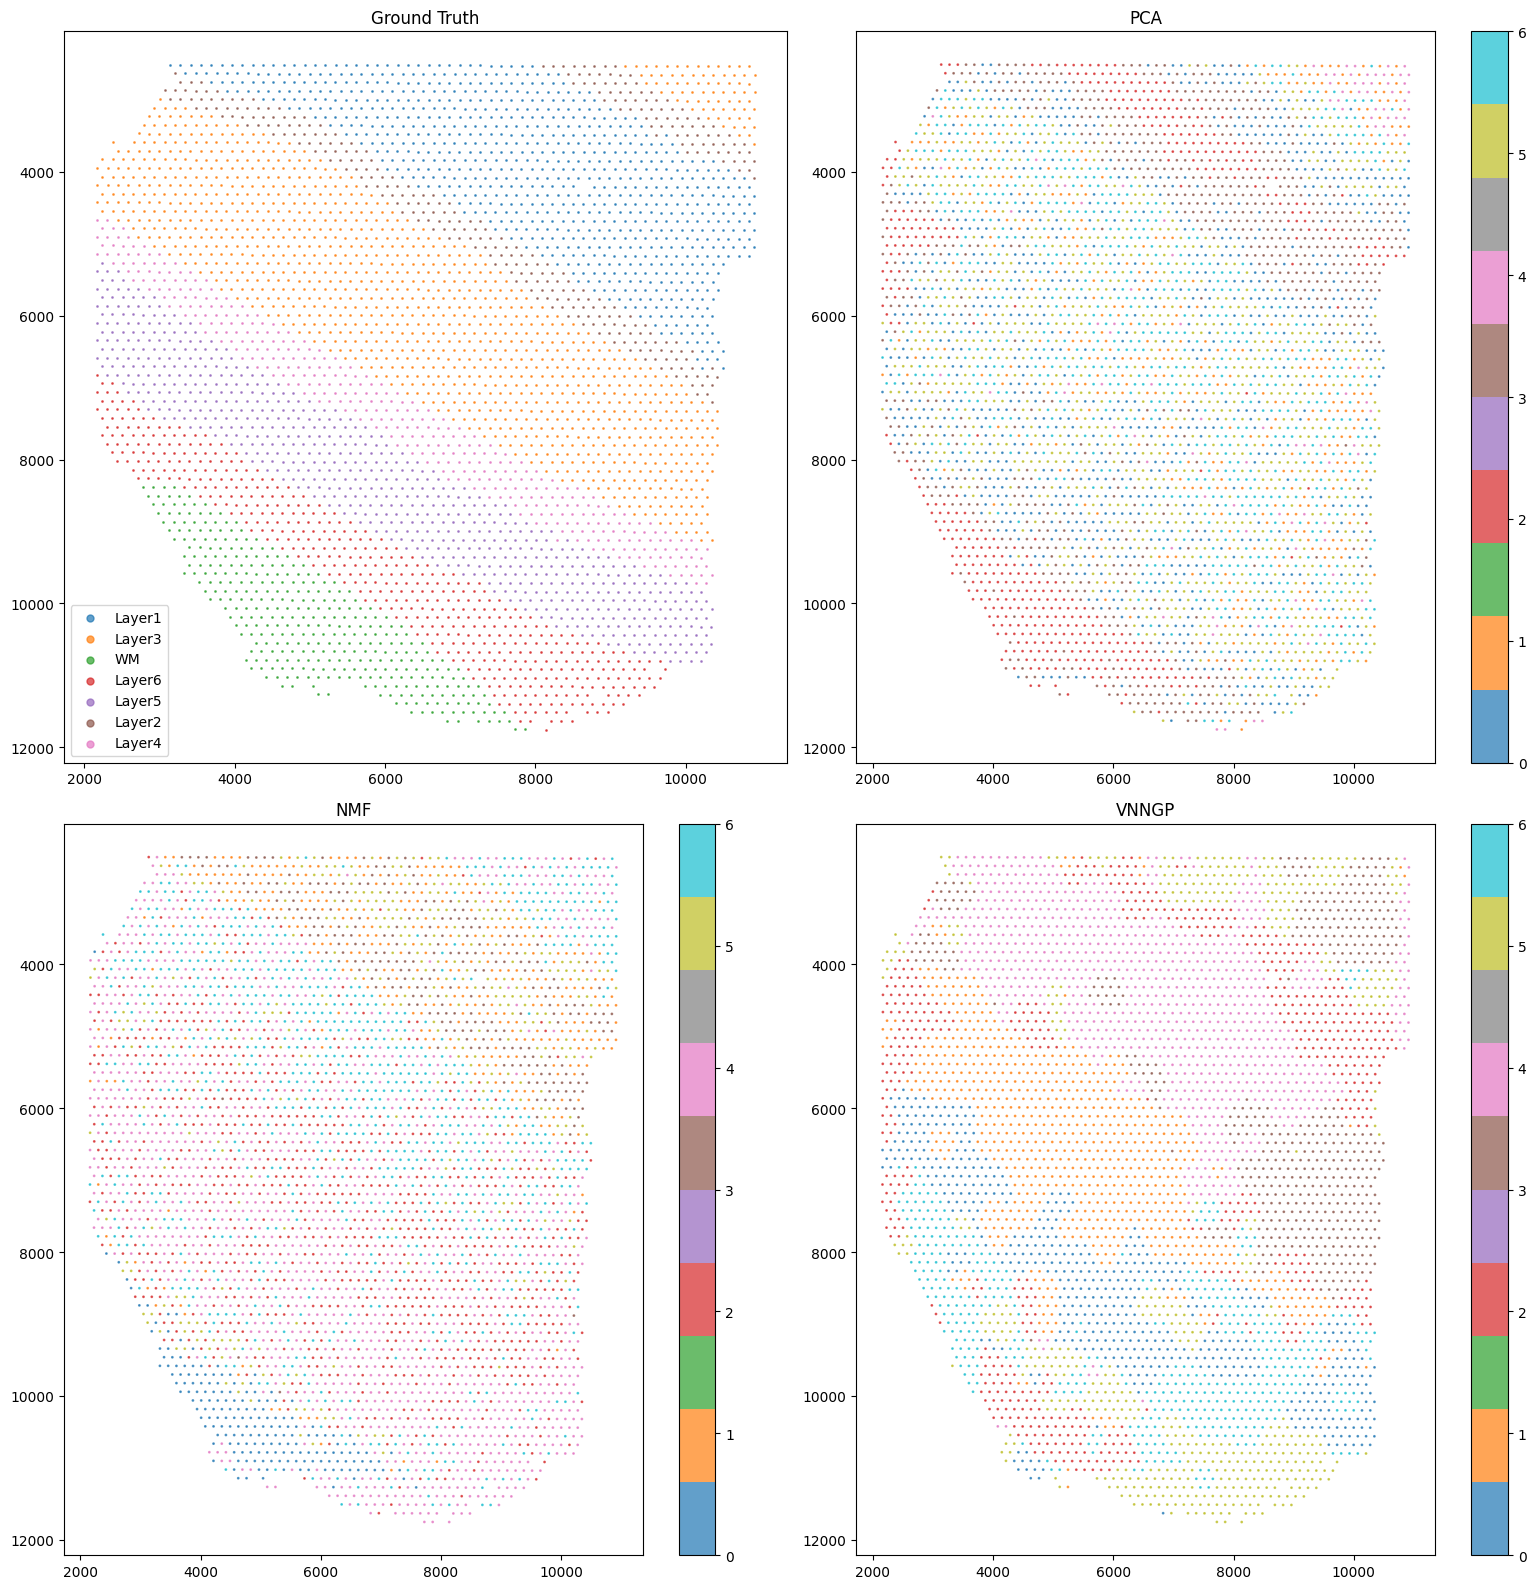

In [16]:
if REGION_COLUMN in adata.obs.columns:
    X_spatial = adata.obsm['spatial']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    
    # Ground truth
    ax = axes[0, 0]
    for region in adata.obs[REGION_COLUMN].unique():
        idx = adata.obs[REGION_COLUMN] == region
        ax.scatter(X_spatial[idx, 0], X_spatial[idx, 1], s=1, label=region, alpha=0.7)
    ax.invert_yaxis()
    ax.set_title('Ground Truth')
    ax.legend(markerscale=5)
    
    # PCA
    ax = axes[0, 1]
    scatter = ax.scatter(X_spatial[:, 0], X_spatial[:, 1], c=pca_labels, s=1, cmap='tab10', alpha=0.7)
    ax.invert_yaxis()
    ax.set_title('PCA')
    plt.colorbar(scatter, ax=ax)
    
    # NMF
    ax = axes[1, 0]
    scatter = ax.scatter(X_spatial[:, 0], X_spatial[:, 1], c=nmf_labels, s=1, cmap='tab10', alpha=0.7)
    ax.invert_yaxis()
    ax.set_title('NMF')
    plt.colorbar(scatter, ax=ax)
    
    # VNNGP or MGGP
    ax = axes[1, 1]
    if 'vnngp_labels' in locals():
        scatter = ax.scatter(X_spatial[:, 0], X_spatial[:, 1], c=vnngp_labels, s=1, cmap='tab10', alpha=0.7)
        ax.set_title('VNNGP')
    elif 'mggp_labels' in locals():
        scatter = ax.scatter(X_spatial[:, 0], X_spatial[:, 1], c=mggp_labels, s=1, cmap='tab10', alpha=0.7)
        ax.set_title('MGGP_VNNGP')
    ax.invert_yaxis()
    plt.colorbar(scatter, ax=ax)
    
    plt.tight_layout()
    plt.show()

## Check for Issues

Common issues to debug:
1. Shape mismatches (should always be N x L for K-means input)
2. All factors are zeros or constants (check min/max/mean)
3. K-means finding only 1 cluster (check factor variation)
4. Sparse matrices not converted to dense

In [17]:
print("\nDEBUG CHECKLIST:")
print("=" * 80)

# 1. Shapes
print("\n1. SHAPES (all should be N x L):")
print(f"   PCA factors: {pca_factors.shape}")
print(f"   NMF factors: {nmf_factors.shape}")
if 'factors_for_kmeans' in locals():
    print(f"   Model factors: {factors_for_kmeans.shape}")

# 2. Factor variation
print("\n2. FACTOR VARIATION:")
print(f"   PCA: min={pca_factors.min():.3f}, max={pca_factors.max():.3f}, std={pca_factors.std():.3f}")
print(f"   NMF: min={nmf_factors.min():.3f}, max={nmf_factors.max():.3f}, std={nmf_factors.std():.3f}")
if 'factors_for_kmeans' in locals():
    print(f"   Model: min={factors_for_kmeans.min():.3f}, max={factors_for_kmeans.max():.3f}, std={factors_for_kmeans.std():.3f}")

# 3. Number of unique clusters found
print("\n3. UNIQUE CLUSTERS FOUND:")
print(f"   PCA: {len(np.unique(pca_labels))} (expected {n_clusters})")
print(f"   NMF: {len(np.unique(nmf_labels))} (expected {n_clusters})")
if 'vnngp_labels' in locals():
    print(f"   VNNGP: {len(np.unique(vnngp_labels))} (expected {n_clusters})")
if 'mggp_labels' in locals():
    print(f"   MGGP: {len(np.unique(mggp_labels))} (expected {n_clusters})")


DEBUG CHECKLIST:

1. SHAPES (all should be N x L):
   PCA factors: (4221, 12)
   NMF factors: (4221, 12)
   Model factors: (4221, 12)

2. FACTOR VARIATION:
   PCA: min=-155.900, max=287.608, std=20.481
   NMF: min=0.000, max=0.119, std=0.007
   Model: min=-9.182, max=2.275, std=1.616

3. UNIQUE CLUSTERS FOUND:
   PCA: 7 (expected 7)
   NMF: 7 (expected 7)
   VNNGP: 7 (expected 7)
   MGGP: 7 (expected 7)
